In [1]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import igraph as ig
import pandas as pd
import numpy as np
import sys

In [2]:
# read network file
#dfpdi = pd.read_csv(sys.argv[1], header = None, sep='\t') # network source target without headers 
dfpdi = pd.read_csv("PDI.pecanpy.input.txt", header = None, sep='\t') # network source target without headers 
dfpdi.columns = ["Source", "Target"]

#name = str(sys.argv[2])
name = "PDI"

In [3]:
Sample_dfpdi = dfpdi.sample(frac=0.01, replace=False, random_state=1)
print(Sample_dfpdi)

filtered = Sample_dfpdi.groupby('Source')['Target'].filter(lambda x: len(x) >= 200)

Sample_dfpdi = Sample_dfpdi[Sample_dfpdi['Target'].isin(filtered)]

print(dfpdi.shape)
print(Sample_dfpdi.shape)

                       Source          Target
248843   pChIP.Zm00001d010634  Zm00001d009850
65629      DAP.Zm00001d015639  Zm00001d025327
807679   pChIP.Zm00001d033719  Zm00001d042721
128336    pChIP.GRMZM2G017586  Zm00001d022038
623586   pChIP.Zm00001d026542  Zm00001d013521
...                       ...             ...
980828   pChIP.Zm00001d042907  Zm00001d007290
64646      DAP.Zm00001d015639  Zm00001d019463
1121649  pChIP.Zm00001d050195  Zm00001d019671
394586   pChIP.Zm00001d016793  Zm00001d020013
349587   pChIP.Zm00001d014995  Zm00001d044254

[11816 rows x 2 columns]
(1181613, 2)
(601, 2)


In [4]:
# make igraph from df
#g = ig.Graph.DataFrame(Sample_dfpdi)
g = ig.Graph.DataFrame(dfpdi)


In [1]:
g.is_simple()


NameError: name 'g' is not defined

In [ ]:
# identify communities

# undirected version, requared to community_multilevel
g_un = g.as_undirected()

# Method 1
community = g_un.community_multilevel()


# Method 2
community2 = g_un.community_edge_betweenness()
# convert it into a flat clustering
#community2 = community2.as_clustering()

# get the membership vector
membersof = community.membership
#membersof2 = community2.membership


In [ ]:
print("h")

In [ ]:
membersof

In [ ]:


nodes = []

for i in range(len(g_un.vs)):
    nodes.append(str(g.vs[i]['name'])) 

out = pd.DataFrame(list(zip(nodes, membersof, membersof2)), columns=['GeneID', "Community1", "Community2"]) 

#out.to_csv("Community."+name+".txt",index=False, sep='\t')

In [ ]:
out

In [ ]:
# Plot before 
layout = g.layout("lgl")
layout = g.layout("fr")

# plot graph
visual_style = {}
visual_style["edge_width"] = 0.05
visual_style["bbox"] = (300, 300)
visual_style["margin"] = 20
visual_style["layout"] = layout

fig, ax = plt.subplots(figsize=(15,15))
ax.axis("off")
ig.plot(g, target=ax, **visual_style)


#fig.savefig("PDI_comunities.pdf", bbox_inches='tight')


AttributeError: 'VertexDendrogram' object has no attribute 'layout'

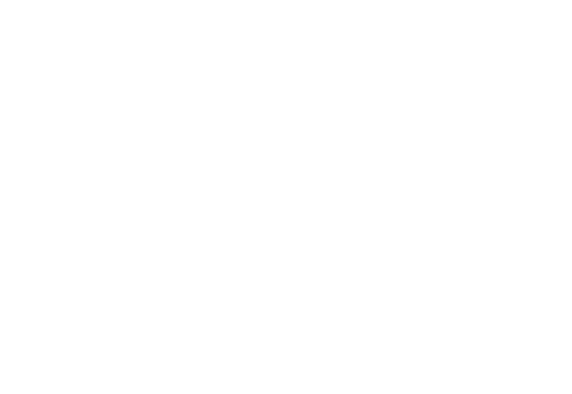

In [134]:
visual_style = {}
visual_style["edge_width"] = 0.05
visual_style["bbox"] = (300, 300)
visual_style["margin"] = 20
visual_style["layout"] = layout

fig, ax = plt.subplots(figsize=(20,14))
ax.axis("off")

ig.plot(community, target=ax, mark_groups = False, **visual_style, color='membership')



fig.savefig("PDI_comunities.pdf", bbox_inches='tight')

In [45]:
import community as community_louvain